In [1]:
import matplotlib.pyplot as plt
import pm4py
import os

import pandas as pd
import numpy as np
import graphviz

os.chdir('..')

os.makedirs('figures', exist_ok=True)

In [2]:
log = pm4py.read_xes('data/BPIChallenge2017.xes.gz')

C:\Users\sophi\anaconda3\Lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


In [ ]:
# --- Basic Counts ---
n_cases = log['case:concept:name'].nunique()
n_events = len(log)

# Process Variants (unique sequences of activities per case)
variants_dict = pm4py.get_variants(log)
n_variants = len(variants_dict)

# --- Attribute Labels ---
case_cols = [col for col in log.columns if col.startswith('case:')]
event_cols = [col for col in log.columns if not col.startswith('case:')]
n_case_attributes = len(case_cols)
n_event_attributes = len(event_cols)

# --- Case Length (number of events per case) ---
case_lengths = log.groupby('case:concept:name').size()
mean_length = case_lengths.mean()
std_length = case_lengths.std()

# --- Case Duration ---
case_duration = log.groupby('case:concept:name')['time:timestamp'].agg(
    lambda x: x.max() - x.min()
)
duration_seconds = case_duration.dt.total_seconds()

mean_dur_days    = duration_seconds.mean() / 86400
std_dur_days     = duration_seconds.std()  / 86400
mean_dur_minutes = duration_seconds.mean() / 60
std_dur_minutes  = duration_seconds.std()  / 60
mean_dur_seconds = duration_seconds.mean()
std_dur_seconds  = duration_seconds.std()

# --- Categorical Event Attributes ---
n_categorical = log[event_cols].select_dtypes(include='object').shape[1]

# --- Summary Table ---
stats = {
    'Metric': [
        'Number of Cases',
        'Number of Events',
        'Number of Process Variants',
        'Number of Case Attribute Labels',
        'Number of Event Attribute Labels',
        'Mean Case Length (events)',
        'Std Case Length (events)',
        'Mean Case Duration (days)',
        'Std Case Duration (days)',
        'Mean Case Duration (minutes)',
        'Std Case Duration (minutes)',
        'Mean Case Duration (seconds)',
        'Std Case Duration (seconds)',
        'Number of Categorical Event Attributes',
    ],
    'Value': [
        n_cases,
        n_events,
        n_variants,
        n_case_attributes,
        n_event_attributes,
        round(mean_length, 2),
        round(std_length, 2),
        round(mean_dur_days, 2),
        round(std_dur_days, 2),
        round(mean_dur_minutes, 2),
        round(std_dur_minutes, 2),
        round(mean_dur_seconds, 2),
        round(std_dur_seconds, 2),
        n_categorical,
    ]
}

df_stats = pd.DataFrame(stats)
display(df_stats)


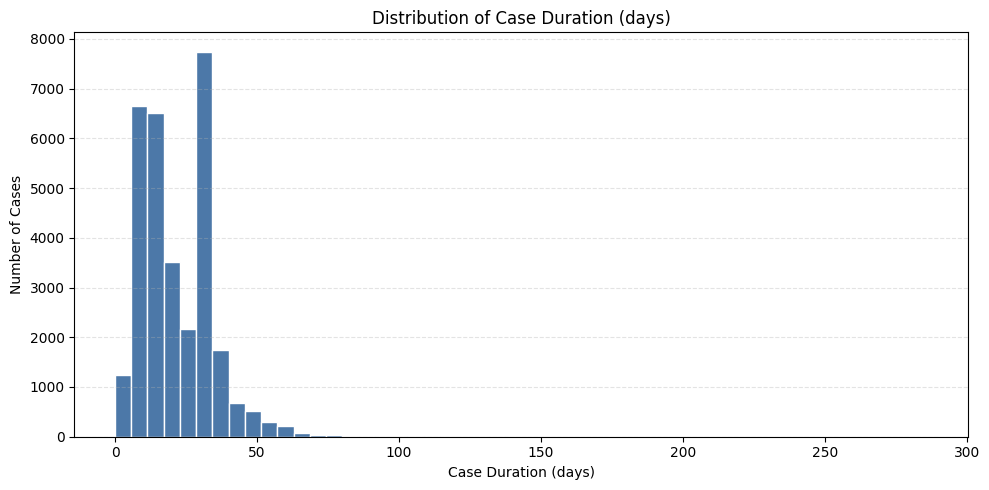

In [5]:
case_duration_days = (
    log.groupby('case:concept:name')['time:timestamp']
    .agg(lambda x: x.max() - x.min())
    .dt.total_seconds() / 86400
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(case_duration_days.dropna(), bins=50, color='#4C78A8', edgecolor='white')
ax.set_title('Distribution of Case Duration (days)')
ax.set_xlabel('Case Duration (days)')
ax.set_ylabel('Number of Cases')
ax.grid(axis='y', linestyle='--', alpha=0.35)

fig.tight_layout()
fig.savefig('figures/case_duration_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
plt.close(fig)

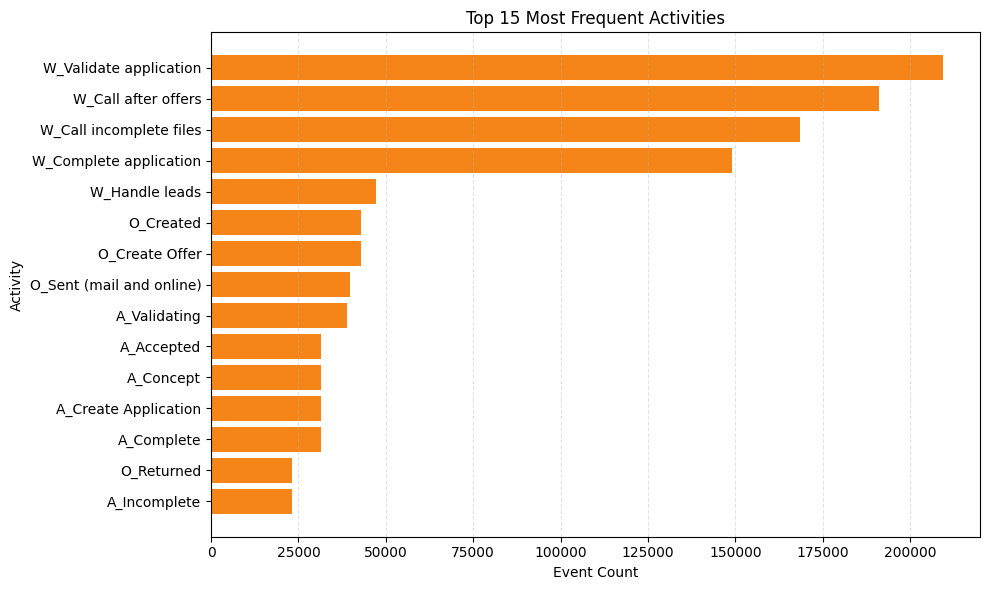

In [4]:
top_n = 15
activity_counts = log['concept:name'].value_counts().head(top_n).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(activity_counts.index, activity_counts.values, color='#F58518')
ax.set_title(f'Top {top_n} Most Frequent Activities')
ax.set_xlabel('Event Count')
ax.set_ylabel('Activity')
ax.grid(axis='x', linestyle='--', alpha=0.35)

fig.tight_layout()
fig.savefig('figures/top_activities_bar.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)

In [6]:
# ============================================================
# Schritt 1: Log filtern (nur complete events)
# ============================================================
log_filtered = log[log['lifecycle:transition'] == 'complete'].copy()

# ============================================================
# Schritt 2: Prozessmodelle discovern
# ============================================================

# --- Inductive Miner ---
net_im, im_im, fm_im = pm4py.discover_petri_net_inductive(
    log_filtered, 
    noise_threshold=0.2  # filtert seltene Pfade raus
)

# --- Heuristics Miner ---
net_hm, im_hm, fm_hm = pm4py.discover_petri_net_heuristics(
    log_filtered,
    dependency_threshold=0.5
)

# ============================================================
# Schritt 3: PM4Py Qualitätsmetriken berechnen
# ============================================================

def compute_pm4py_metrics(log, net, im, fm, name):
    print(f"\n{'='*50}")
    print(f"Metriken für: {name}")
    print(f"{'='*50}")
    
    # Fitness (Token-based Replay)
    fitness = pm4py.fitness_token_based_replay(log, net, im, fm)
    print(f"Fitness (token-based):     {fitness['average_trace_fitness']:.4f}")
    
    # Precision
    precision = pm4py.precision_token_based_replay(log, net, im, fm)
    print(f"Precision (token-based):   {precision:.4f}")
    
    # Generalization
    generalization = pm4py.generalization_tbr(log, net, im, fm)
    print(f"Generalization:            {generalization:.4f}")
    
    # Simplicity
    simplicity = pm4py.simplicity_petri_net(net)
    print(f"Simplicity (pm4py):        {simplicity:.4f}")
    
    return {
        'Model': name,
        'Fitness': round(fitness['average_trace_fitness'], 4),
        'Precision': round(precision, 4),
        'Generalization': round(generalization, 4),
        'Simplicity (pm4py)': round(simplicity, 4),
    }

results = []
results.append(compute_pm4py_metrics(log_filtered, net_im, im_im, fm_im, "Inductive Miner"))
results.append(compute_pm4py_metrics(log_filtered, net_hm, im_hm, fm_hm, "Heuristics Miner"))

# ============================================================
# Schritt 4: Eigene Simplicity Metriken (Pflicht!)
# ============================================================
# Das Assignment verlangt mind. 2 selbst implementierte 
# Simplicity Metriken in Python

def simplicity_arc_degree(net):
    """
    Durchschnittlicher Knotengrad im Netz.
    Niedrigerer Wert = einfacheres Modell.
    Normalisiert auf [0,1]: 1 = simpel, 0 = komplex.
    Referenz: Carmona et al. (2018)
    """
    n_nodes = len(net.places) + len(net.transitions)
    n_arcs = len(net.arcs)
    
    if n_nodes == 0:
        return 0
    
    avg_degree = (2 * n_arcs) / n_nodes  # jeder Arc zählt für 2 Knoten
    # Normalisierung: 1/(1 + avg_degree) → 1 wenn degree=0, → 0 wenn degree=∞
    return round(1 / (1 + avg_degree), 4)


def simplicity_structure(net):
    """
    Verhältnis von Transitions zu (Places + Transitions).
    Misst strukturelle Ausgewogenheit des Netzes.
    Wert nahe 0.5 = ausgewogen = simpel.
    Referenz: Carmona et al. (2018)
    """
    n_places = len(net.places)
    n_transitions = len(net.transitions)
    total = n_places + n_transitions
    
    if total == 0:
        return 0
    
    ratio = n_transitions / total
    # Symmetrie um 0.5: 1 wenn perfekt ausgewogen, 0 wenn nur Places oder nur Transitions
    return round(1 - abs(ratio - 0.5) * 2, 4)


# Metriken für alle Modelle berechnen
for result, (net, name) in zip(results, [
    (net_im, "Inductive Miner"),
    (net_hm, "Heuristics Miner")
]):
    s1 = simplicity_arc_degree(net)
    s2 = simplicity_structure(net)
    result['Simplicity (Arc Degree)'] = s1
    result['Simplicity (Structure)'] = s2
    print(f"\n{name}:")
    print(f"  Simplicity Arc Degree:  {s1}")
    print(f"  Simplicity Structure:   {s2}")
    print(f"  Anzahl Places:          {len(net.places)}")
    print(f"  Anzahl Transitions:     {len(net.transitions)}")
    print(f"  Anzahl Arcs:            {len(net.arcs)}")

# ============================================================
# Schritt 5: Ergebnistabelle
# ============================================================
df_results = pd.DataFrame(results)
display(df_results)


Metriken für: Inductive Miner


replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Fitness (token-based):     0.9905


replaying log with TBR, completed traces ::   0%|          | 0/27816 [00:00<?, ?it/s]

Precision (token-based):   0.3367


replaying log with TBR, completed traces ::   0%|          | 0/5623 [00:00<?, ?it/s]

Generalization:            0.9803


TypeError: simplicity_petri_net() missing 2 required positional arguments: 'im' and 'fm'

In [8]:
status_events = {
    "approved": "A_Accepted",
    "rejected": "A_Denied",
    "cancelled": "A_Cancelled",
}

# Filter to only 'complete' lifecycle events
log_filtered = log[log['lifecycle:transition'] == 'complete'].copy()
print(f"Incomplete cases removed: {log['case:concept:name'].nunique() - log_filtered['case:concept:name'].nunique()}")

Incomplete cases removed: 0


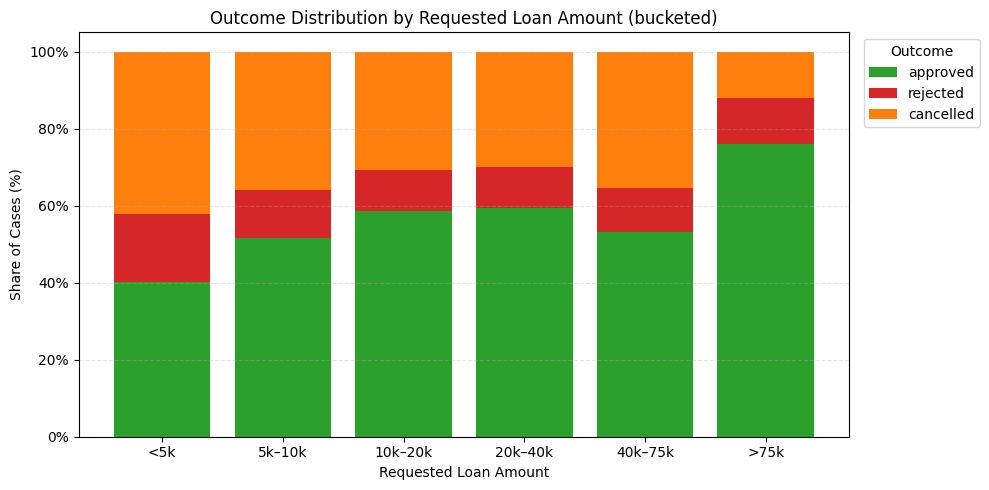

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

os.makedirs('figures', exist_ok=True)

# --- Build case-level outcome + requested amount table ---
case_outcome = case_status[["case:concept:name", "status"]].copy()

case_amount = (
    log.dropna(subset=["case:RequestedAmount"])
    .groupby("case:concept:name")["case:RequestedAmount"]
    .first()
    .reset_index()
)

df_plot = case_outcome.merge(case_amount, on="case:concept:name", how="inner")

# Bin requested amounts
bins = [0, 5_000, 10_000, 20_000, 40_000, 75_000, np.inf]
labels = ["<5k", "5k–10k", "10k–20k", "20k–40k", "40k–75k", ">75k"]
df_plot["amount_bin"] = pd.cut(df_plot["case:RequestedAmount"], bins=bins, labels=labels)

# Stacked bar: count per (bin, status)
pivot = (
    df_plot.groupby(["amount_bin", "status"], observed=True)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=["approved", "rejected", "cancelled"], fill_value=0)
)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

colors = {"approved": "#2ca02c", "rejected": "#d62728", "cancelled": "#ff7f0e"}

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(pivot_pct))
for status, color in colors.items():
    ax.bar(pivot_pct.index.astype(str), pivot_pct[status], bottom=bottom,
           label=status, color=color)
    bottom += pivot_pct[status].values

ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title("Outcome Distribution by Requested Loan Amount (bucketed)")
ax.set_xlabel("Requested Loan Amount")
ax.set_ylabel("Share of Cases (%)")
ax.legend(title="Outcome", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.tight_layout()
fig.savefig("figures/outcome_by_loan_amount.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


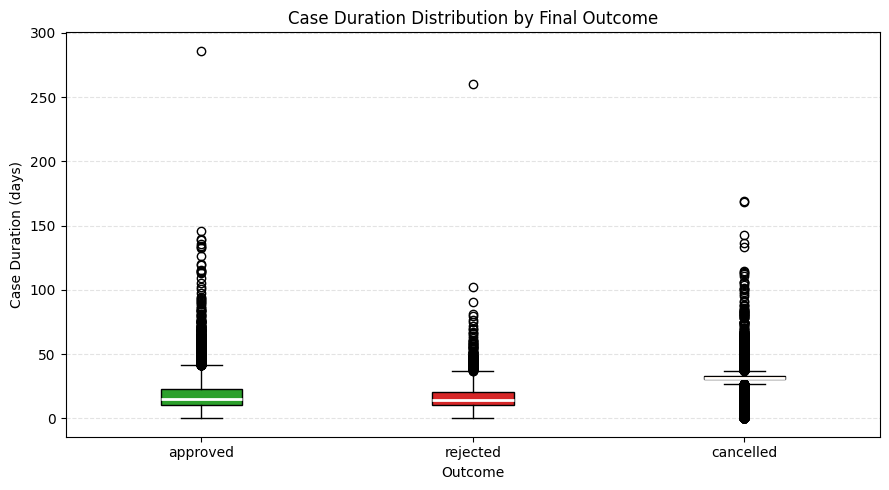

In [10]:
import matplotlib.pyplot as plt

os.makedirs('figures', exist_ok=True)

# --- Build case-level outcome + duration table ---
case_dur_days = (
    log.groupby("case:concept:name")["time:timestamp"]
    .agg(lambda x: x.max() - x.min())
    .dt.total_seconds() / 86400
).reset_index(name="duration_days")

df_dur = case_outcome.merge(case_dur_days, on="case:concept:name", how="inner")

order = ["approved", "rejected", "cancelled"]
colors = {"approved": "#2ca02c", "rejected": "#d62728", "cancelled": "#ff7f0e"}

data = [df_dur.loc[df_dur["status"] == s, "duration_days"].dropna().values for s in order]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, patch_artist=True, notch=False,
                medianprops=dict(color="white", linewidth=2))

for patch, status in zip(bp["boxes"], order):
    patch.set_facecolor(colors[status])

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order)
ax.set_title("Case Duration Distribution by Final Outcome")
ax.set_xlabel("Outcome")
ax.set_ylabel("Case Duration (days)")
ax.grid(axis="y", linestyle="--", alpha=0.35)

fig.tight_layout()
fig.savefig("figures/case_duration_by_outcome.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
